In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("DateFruit_Dataset.csv")

In [3]:
data

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.9080,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.1440,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.3940,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.2100,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.3540,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,255403,1925.3650,691.8453,477.1796,0.7241,570.2536,0.9785,261028,0.7269,1.4499,...,2.2423,2.3704,2.7202,-25296416768,-19168882688,-18473392128,49.0869,43.0422,42.4153,SOGAY
894,365924,2664.8230,855.4633,551.5447,0.7644,682.5752,0.9466,386566,0.6695,1.5510,...,3.4109,3.5805,3.9910,-31605219328,-21945366528,-19277905920,46.8086,39.1046,36.5502,SOGAY
895,254330,1926.7360,747.4943,435.6219,0.8126,569.0545,0.9925,256255,0.7240,1.7159,...,2.2759,2.5090,2.6951,-22242772992,-19594921984,-17592152064,44.1325,40.7986,40.9769,SOGAY
896,238955,1906.2679,716.6485,441.8297,0.7873,551.5859,0.9604,248795,0.6954,1.6220,...,2.6769,2.6874,2.7991,-26048595968,-21299822592,-19809978368,51.2267,45.7162,45.6260,SOGAY


In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["Class"] = le.fit_transform(data["Class"])

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

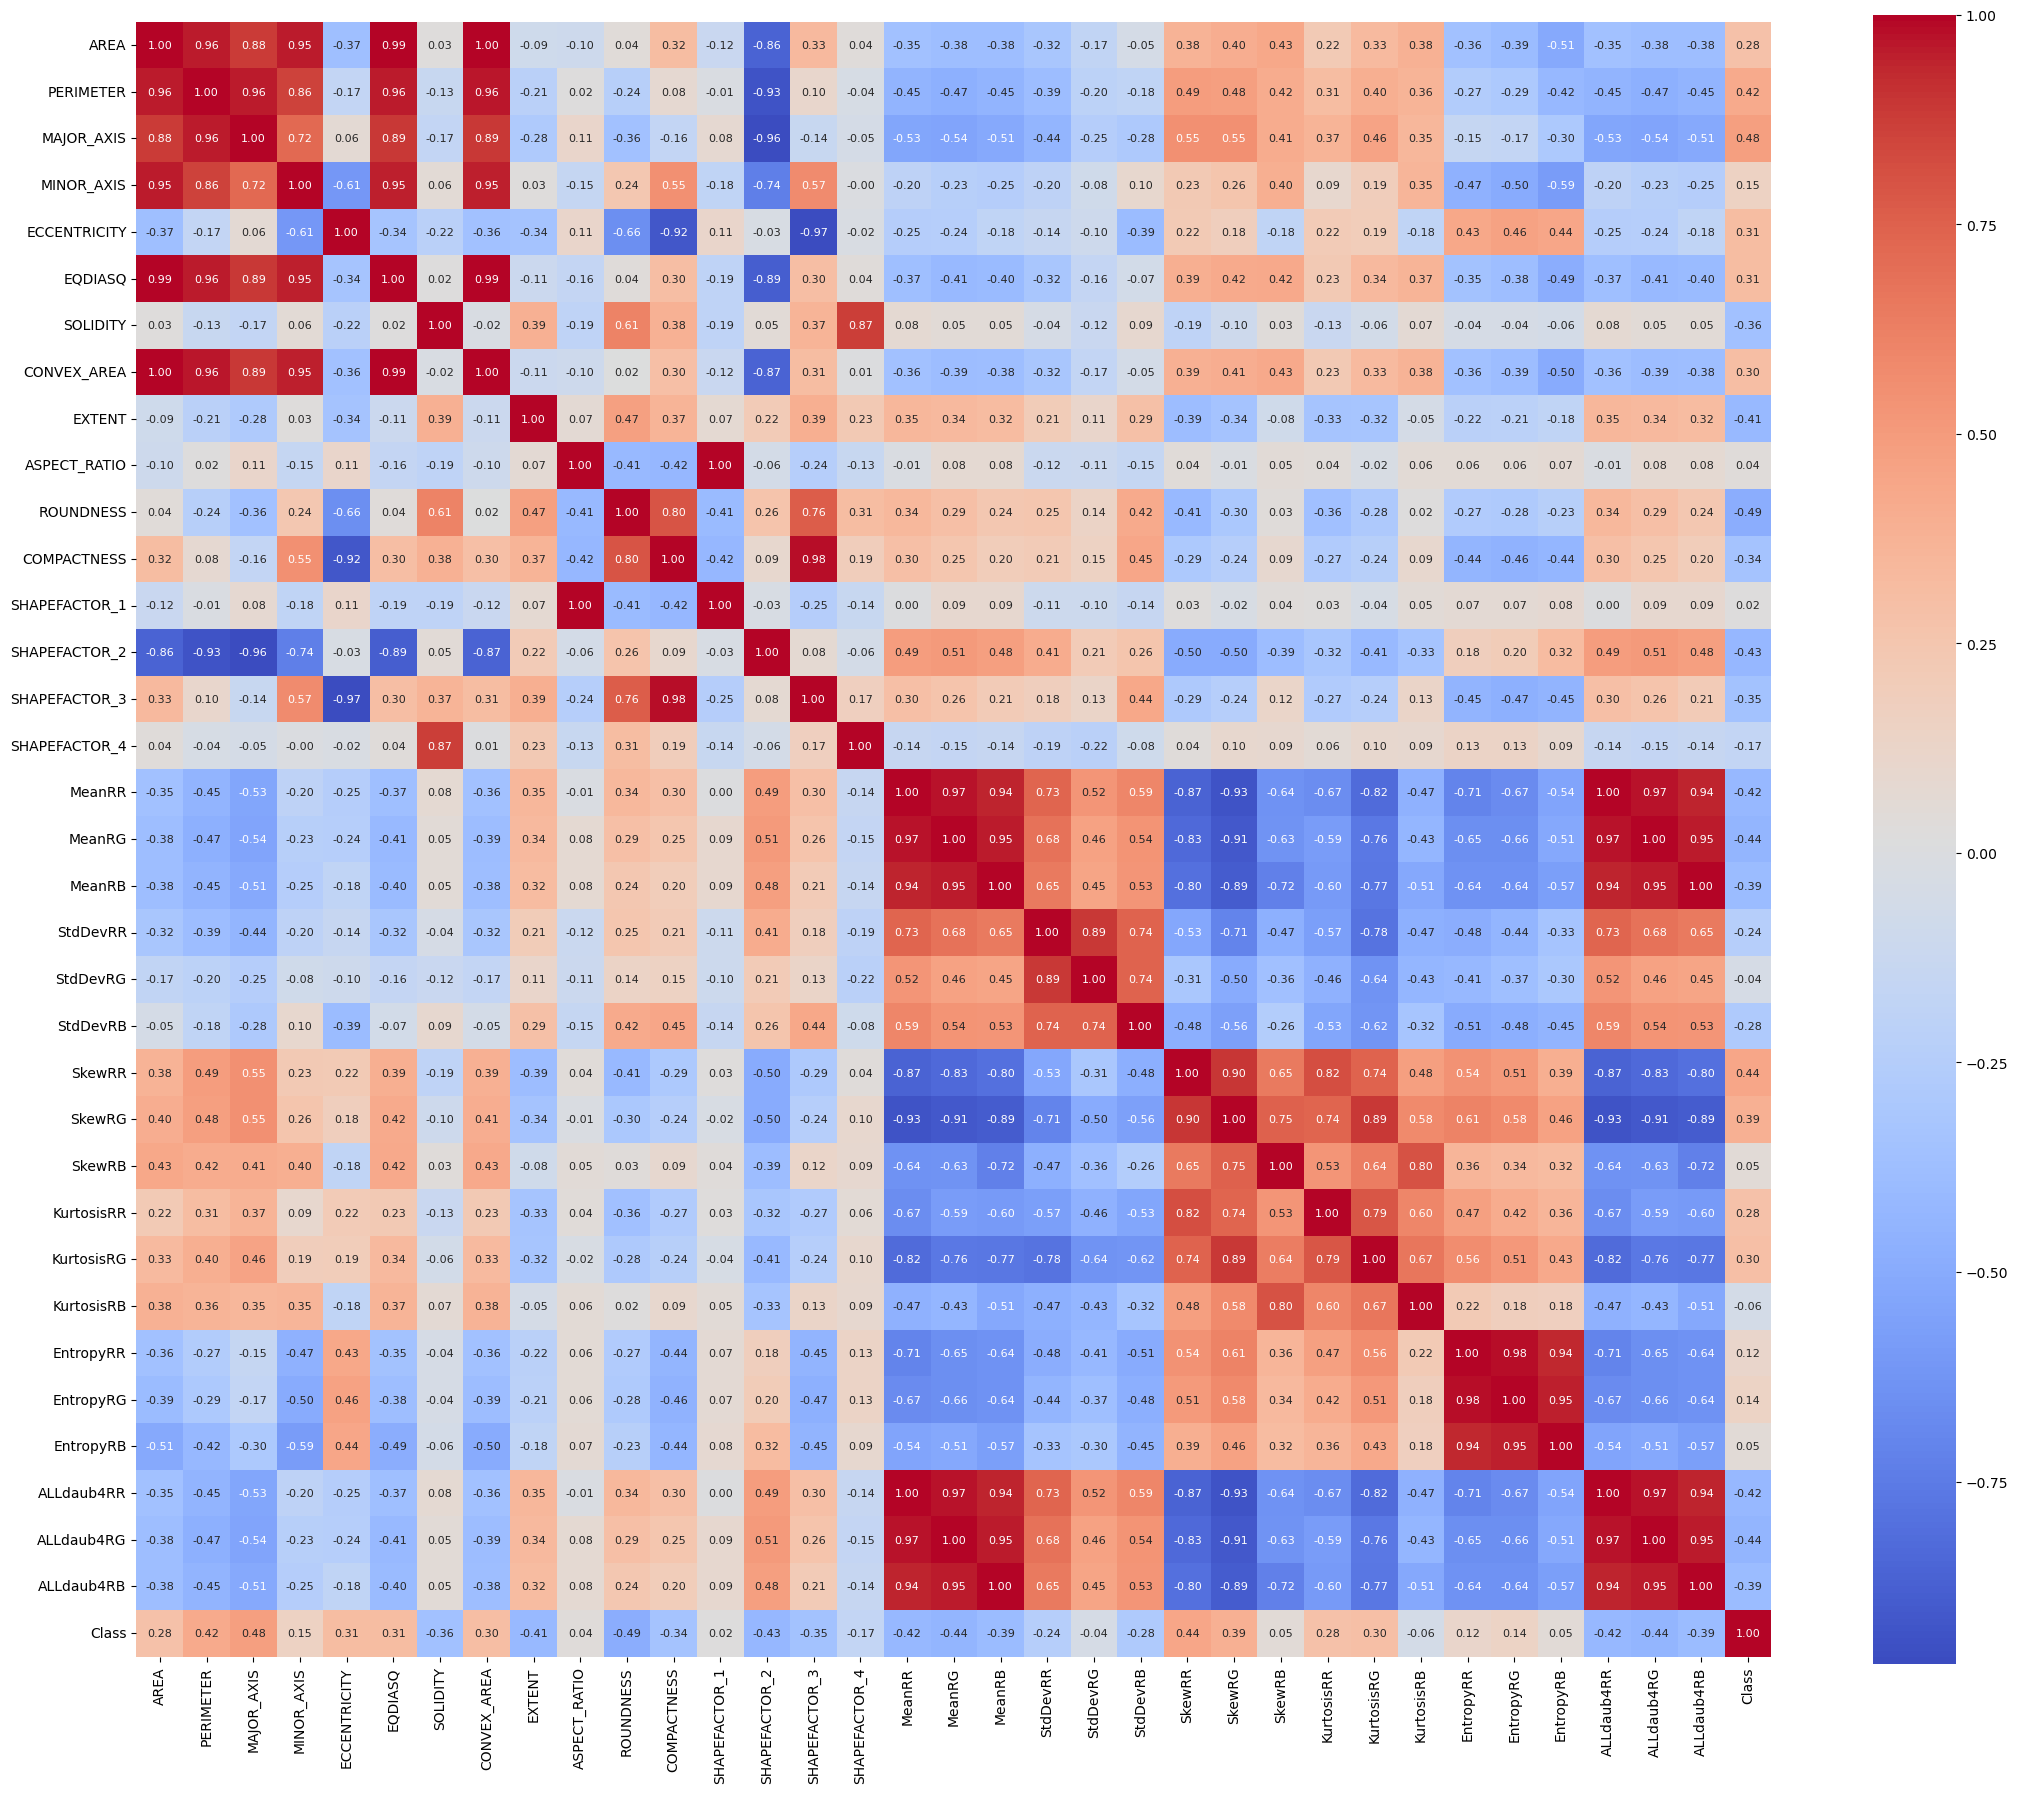

In [17]:
plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm", 
    annot=True, 
    fmt=".2f",              
    annot_kws={"size": 8},
    square=True
)

plt.tight_layout()
plt.show()

In [18]:
class_correlations = corr_matrix['Class'].drop('Class').sort_values(ascending=False)


print("Highest Positive Correlations:")
print(class_correlations.head())

print("\n-------------------------------\n")


print("Highest Negative Correlations:")
print(class_correlations.tail())

Highest Positive Correlations:
MAJOR_AXIS      0.479079
SkewRR          0.440968
PERIMETER       0.420245
SkewRG          0.390856
ECCENTRICITY    0.311292
Name: Class, dtype: float64

-------------------------------

Highest Negative Correlations:
MeanRR          -0.416424
SHAPEFACTOR_2   -0.425621
MeanRG          -0.444107
ALLdaub4RG      -0.444114
ROUNDNESS       -0.488274
Name: Class, dtype: float64


In [19]:
X = data.drop("Class",axis=1)
y = data["Class"]

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

# Logistic regression

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [37]:
pipe_lr = Pipeline ([
    ("scaler",StandardScaler()),
    ("lr",LogisticRegression()),
    
])
pipe_lr.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work 

Overall Accuracy : 0.9278

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.83      0.75      0.79        20
           2       0.95      0.95      0.95        41
           3       0.93      1.00      0.97        14
           4       0.94      0.97      0.96        33
           5       0.95      1.00      0.98        40
           6       0.83      0.79      0.81        19

    accuracy                           0.93       180
   macro avg       0.92      0.91      0.92       180
weighted avg       0.93      0.93      0.93       180


-------------------------------



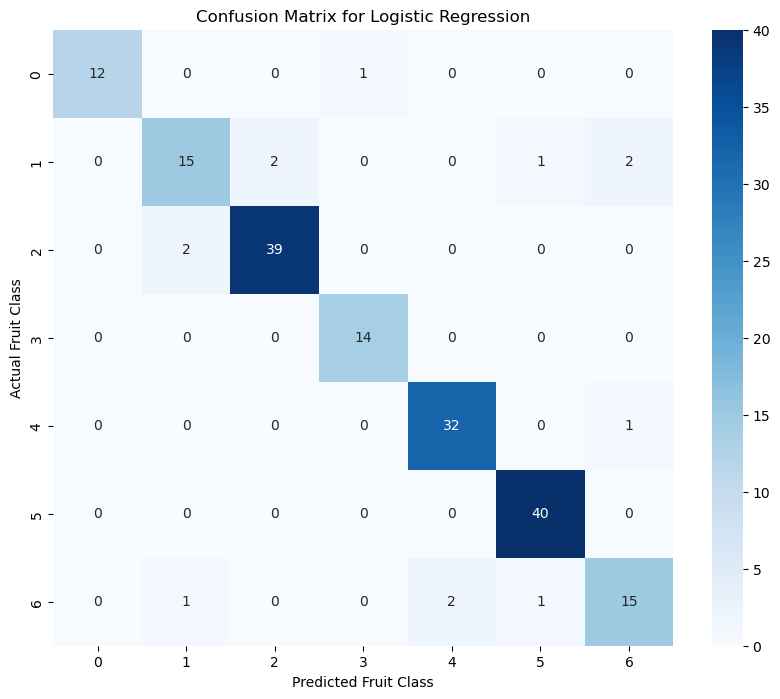

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred=pipe_lr.predict(X_test)
acc = accuracy_score(y_test,y_pred)
print(f"Overall Accuracy : {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


print("\n-------------------------------\n")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual Fruit Class')
plt.xlabel('Predicted Fruit Class')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [43]:
from sklearn.model_selection import cross_val_score,GridSearchCV
cv_scores = cross_val_score(pipe_lr, X, y, cv=5, scoring='accuracy')


print("Accuracy scores for each of the 5 folds:")
print(cv_scores)
print("\n-------------------------------\n")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Accuracy scores for each of the 5 folds:
[0.91666667 0.91111111 0.92777778 0.91061453 0.90502793]

-------------------------------

Mean CV Accuracy: 0.9142
Standard Deviation: 0.0077


# Random Forest Classifier

In [44]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=5,
    max_features="sqrt",
    random_state = 42
)

    
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'min_samples_leaf':[2,3,5,7],
    'min_samples_split':[3,5,7]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train,y_train)
best_rf=grid.best_estimator_

Random Forest Accuracy: 0.9222

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.83      0.75      0.79        20
           2       0.97      0.95      0.96        41
           3       0.93      1.00      0.97        14
           4       0.97      0.97      0.97        33
           5       1.00      0.95      0.97        40
           6       0.68      0.89      0.77        19

    accuracy                           0.92       180
   macro avg       0.91      0.91      0.91       180
weighted avg       0.93      0.92      0.92       180


---------------------



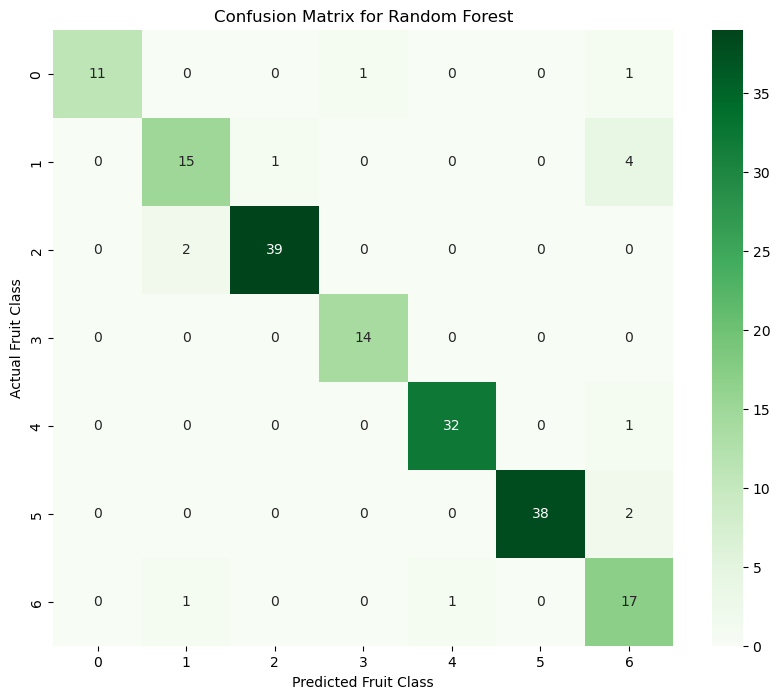

In [49]:
y_pred_rf = best_rf.predict(X_test)


acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}\n")


print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n---------------------\n")
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')  
plt.ylabel('Actual Fruit Class')
plt.xlabel('Predicted Fruit Class')
plt.title('Confusion Matrix for Random Forest')
plt.show()

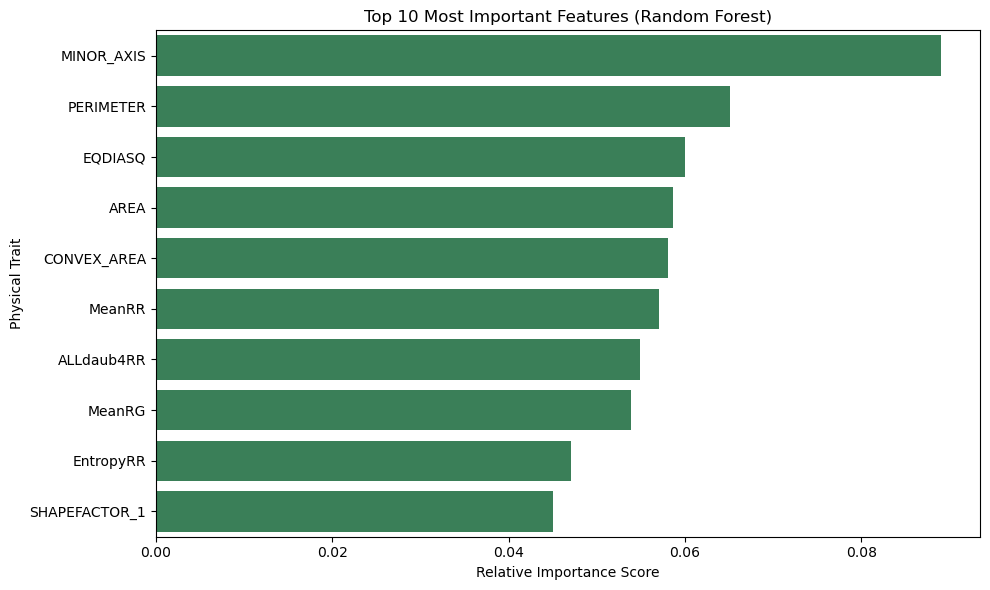

In [51]:
importances = best_rf.feature_importances_


feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(10), 
    color='seagreen' 
)

plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Physical Trait')
plt.tight_layout()
plt.show()